# 比较情绪分析结果

这个 notebook 用来比较不同结果目录中的 `sentiment_results.parquet`（如果 parquet 不存在，则自动回退到 `sentiment_results.jsonl`）。

分析内容包括：

- 各结果文件的样本量与字段检查
- 不同结果之间 `id` 交集规模统计
- 三组结果所有 pair 在交集样本上的 `sentiment_score` 与 `confidence` 对比
- 差值分布、散点图和相关性热图
- 各 pair 差异最大的样本明细

默认已经配置为比较：

- `4_v2`
- `4_structured_input`
- `4_golden_structured_input`

如果你后续新增了更多结果目录，只需要在下一格的 `RESULT_FILES` 中补充路径，并调整 `PAIRS_TO_COMPARE` 即可。


In [5]:
from pathlib import Path
import json
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

BASE_DIR = Path(r"D:\AQUMON\data\results\4")

RESULT_FILES = {
    "4_v2": BASE_DIR / "4_v2" / "sentiment_results.parquet",
    "4_structured_input": BASE_DIR / "4_structured_input" / "sentiment_results.parquet",
    "4_golden_structured_input": BASE_DIR / "4_golden_structured_input" / "sentiment_results.parquet",
}

PAIRS_TO_COMPARE = [
    ("4_v2", "4_structured_input"),
    ("4_v2", "4_golden_structured_input"),
    ("4_structured_input", "4_golden_structured_input"),
]
TOP_N_DIFFS = 20


In [6]:
def confidence_to_float(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    text = text.replace("%", "")
    try:
        return float(text)
    except ValueError:
        return np.nan


def read_results_table(path: Path) -> pd.DataFrame:
    parquet_path = Path(path)
    jsonl_path = parquet_path.with_suffix(".jsonl")

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = parquet_path
    elif jsonl_path.exists():
        records = []
        with jsonl_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                line = line.strip()
                if not line:
                    continue
                records.append(json.loads(line))
        df = pd.DataFrame(records)
        source = jsonl_path
    else:
        raise FileNotFoundError(f"Neither parquet nor jsonl exists for {parquet_path}")

    required_columns = {"id", "sentiment_score", "confidence"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns {missing_columns} in {source}")

    standardized = df.copy()
    standardized["id"] = standardized["id"].astype(str)
    standardized["sentiment_score"] = pd.to_numeric(standardized["sentiment_score"], errors="coerce")
    standardized["confidence_pct"] = standardized["confidence"].map(confidence_to_float)
    standardized["source_path"] = str(source)
    return standardized


def load_all_results(result_files: dict[str, Path]) -> dict[str, pd.DataFrame]:
    loaded = {}
    for name, path in result_files.items():
        loaded[name] = read_results_table(path)
    return loaded


def build_dataset_summary(result_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in result_tables.items():
        rows.append({
            "dataset": name,
            "rows": len(df),
            "unique_ids": df["id"].nunique(),
            "score_non_null": df["sentiment_score"].notna().sum(),
            "confidence_non_null": df["confidence_pct"].notna().sum(),
            "score_mean": df["sentiment_score"].mean(),
            "confidence_mean": df["confidence_pct"].mean(),
            "source_path": df["source_path"].iloc[0],
        })
    return pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)


def build_pairwise_overlap_summary(result_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    id_sets = {name: set(df["id"]) for name, df in result_tables.items()}
    for left_name, right_name in combinations(result_tables.keys(), 2):
        left_ids = id_sets[left_name]
        right_ids = id_sets[right_name]
        overlap = left_ids & right_ids
        union = left_ids | right_ids
        rows.append({
            "left": left_name,
            "right": right_name,
            "left_rows": len(left_ids),
            "right_rows": len(right_ids),
            "intersection_rows": len(overlap),
            "union_rows": len(union),
            "jaccard": len(overlap) / len(union) if union else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["intersection_rows", "left", "right"], ascending=[False, True, True]).reset_index(drop=True)


def compare_pair(result_tables: dict[str, pd.DataFrame], left_name: str, right_name: str) -> pd.DataFrame:
    left = result_tables[left_name][["id", "sentiment_score", "confidence", "confidence_pct", "summary"]].copy()
    right = result_tables[right_name][["id", "sentiment_score", "confidence", "confidence_pct", "summary"]].copy()

    merged = left.merge(
        right,
        on="id",
        how="inner",
        suffixes=(f"_{left_name}", f"_{right_name}"),
    )

    merged["sentiment_score_diff"] = merged[f"sentiment_score_{right_name}"] - merged[f"sentiment_score_{left_name}"]
    merged["sentiment_score_abs_diff"] = merged["sentiment_score_diff"].abs()
    merged["confidence_pct_diff"] = merged[f"confidence_pct_{right_name}"] - merged[f"confidence_pct_{left_name}"]
    merged["confidence_pct_abs_diff"] = merged["confidence_pct_diff"].abs()
    return merged.sort_values(["sentiment_score_abs_diff", "confidence_pct_abs_diff"], ascending=False).reset_index(drop=True)


result_tables = load_all_results(RESULT_FILES)
dataset_summary = build_dataset_summary(result_tables)
pairwise_overlap_summary = build_pairwise_overlap_summary(result_tables)
comparison_tables = {pair: compare_pair(result_tables, *pair) for pair in PAIRS_TO_COMPARE}

print("Dataset summary")
display(dataset_summary)

print("Pairwise overlap summary")
display(pairwise_overlap_summary)

for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = comparison_tables[(left_name, right_name)]
    print(f"Detailed comparison pair: {left_name} vs {right_name}")
    print(f"Intersection rows: {len(pair_df)}")
    display(pair_df.head())


Dataset summary


,dataset,rows,unique_ids,score_non_null,confidence_non_null,score_mean,confidence_mean,source_path
0,4_golden_structured_input,54,54,54,54,0.222222,86.481481,D:\AQUMON\data\results\4\4_golden_structured_i...
1,4_structured_input,54,54,54,54,0.262963,89.166667,D:\AQUMON\data\results\4\4_structured_input\se...
2,4_v2,26262,26262,26262,26262,0.046501,88.166057,D:\AQUMON\data\results\4\4_v2\sentiment_result...


Pairwise overlap summary


,left,right,left_rows,right_rows,intersection_rows,union_rows,jaccard
0,4_structured_input,4_golden_structured_input,54,54,54,54,1.000000
1,4_v2,4_golden_structured_input,26262,54,54,26262,0.002056
2,4_v2,4_structured_input,26262,54,54,26262,0.002056


Detailed comparison pair: 4_v2 vs 4_structured_input
Intersection rows: 54


,id,sentiment_score_4_v2,confidence_4_v2,confidence_pct_4_v2,summary_4_v2,sentiment_score_4_structured_input,confidence_4_structured_input,confidence_pct_4_structured_input,summary_4_structured_input,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0001213900-24-034233,0.5,85%,85.0,This filing indicates a moderately positive se...,0.8,95%,95.0,This filing indicates a strongly positive insi...,0.3,0.3,10.0,10.0
1,0001209191-20-021443,0.3,75%,75.0,This filing indicates a moderately positive in...,0.0,85%,85.0,"This filing reports an SVP exercising 5,000 em...",-0.3,0.3,10.0,10.0
2,0001209191-20-021889,0.4,95%,95.0,This filing reflects a moderately positive ins...,0.7,95%,95.0,This filing indicates a strongly positive insi...,0.3,0.3,0.0,0.0
3,0001209191-20-016737,0.7,90%,90.0,This filing shows a strongly positive insider ...,0.4,90%,90.0,This filing reflects a moderately positive ins...,-0.3,0.3,0.0,0.0
4,0000899243-20-008213,0.7,90%,90.0,This filing indicates a strongly positive sent...,0.9,95%,95.0,This filing demonstrates strongly positive ins...,0.2,0.2,5.0,5.0


Detailed comparison pair: 4_v2 vs 4_golden_structured_input
Intersection rows: 54


,id,sentiment_score_4_v2,confidence_4_v2,confidence_pct_4_v2,summary_4_v2,sentiment_score_4_golden_structured_input,confidence_4_golden_structured_input,confidence_pct_4_golden_structured_input,summary_4_golden_structured_input,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0001209191-20-015600,0.8,95%,95.0,This filing shows a strong positive insider se...,0.3,80%,80.0,The Chairman and CEO acquired a significant nu...,-0.5,0.5,-15.0,15.0
1,0001209191-22-028778,0.8,95%,95.0,This filing details multiple open-market purch...,0.3,80%,80.0,This filing reports a cluster of five discreti...,-0.5,0.5,-15.0,15.0
2,0001209191-20-016737,0.7,90%,90.0,This filing shows a strongly positive insider ...,0.3,80%,80.0,A director made a discretionary open market pu...,-0.4,0.4,-10.0,10.0
3,0001209191-20-021443,0.3,75%,75.0,This filing indicates a moderately positive in...,0.0,80%,80.0,"This filing reports the acquisition of 5,000 c...",-0.3,0.3,5.0,5.0
4,0000064040-23-000067,-0.3,75%,75.0,This filing suggests a slightly negative senti...,-0.6,75%,75.0,"Saugata Saha, President of Commodity Insights ...",-0.3,0.3,0.0,0.0


Detailed comparison pair: 4_structured_input vs 4_golden_structured_input
Intersection rows: 54


,id,sentiment_score_4_structured_input,confidence_4_structured_input,confidence_pct_4_structured_input,summary_4_structured_input,sentiment_score_4_golden_structured_input,confidence_4_golden_structured_input,confidence_pct_4_golden_structured_input,summary_4_golden_structured_input,sentiment_score_diff,sentiment_score_abs_diff,confidence_pct_diff,confidence_pct_abs_diff
0,0001209191-22-028778,0.8,95%,95.0,This filing details multiple substantial open-...,0.3,80%,80.0,This filing reports a cluster of five discreti...,-0.5,0.5,-15.0,15.0
1,0001209191-20-015600,0.7,95%,95.0,This filing suggests a strongly positive insid...,0.3,80%,80.0,The Chairman and CEO acquired a significant nu...,-0.4,0.4,-15.0,15.0
2,0001209191-18-061223,-0.3,85%,85.0,The CEO and Chairman exercised a substantial n...,0.0,90%,90.0,"This filing shows the Chairman, President & CE...",0.3,0.3,5.0,5.0
3,0000064040-23-000067,-0.3,80%,80.0,This filing indicates a slightly negative insi...,-0.6,75%,75.0,"Saugata Saha, President of Commodity Insights ...",-0.3,0.3,-5.0,5.0
4,0000933036-21-000095,0.7,90%,90.0,This filing indicates a strongly positive sent...,0.4,70%,70.0,"Director Jeffrey J. Brown made a large, discre...",-0.3,0.3,-20.0,20.0


In [7]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = comparison_tables[(left_name, right_name)]
    intersection_rows = len(pair_df)
    sentiment_corr = (
        pair_df[[f"sentiment_score_{left_name}", f"sentiment_score_{right_name}"]].corr().iloc[0, 1]
        if intersection_rows >= 2
        else np.nan
    )
    confidence_corr = (
        pair_df[[f"confidence_pct_{left_name}", f"confidence_pct_{right_name}"]].corr().iloc[0, 1]
        if intersection_rows >= 2
        else np.nan
    )

    summary_stats = pd.DataFrame([
        {"metric": "intersection_rows", "value": intersection_rows},
        {"metric": f"mean_sentiment_score_{left_name}", "value": pair_df[f"sentiment_score_{left_name}"].mean()},
        {"metric": f"mean_sentiment_score_{right_name}", "value": pair_df[f"sentiment_score_{right_name}"].mean()},
        {"metric": "mean_sentiment_score_abs_diff", "value": pair_df["sentiment_score_abs_diff"].mean()},
        {"metric": f"mean_confidence_pct_{left_name}", "value": pair_df[f"confidence_pct_{left_name}"].mean()},
        {"metric": f"mean_confidence_pct_{right_name}", "value": pair_df[f"confidence_pct_{right_name}"].mean()},
        {"metric": "mean_confidence_pct_abs_diff", "value": pair_df["confidence_pct_abs_diff"].mean()},
        {"metric": "sentiment_score_corr", "value": sentiment_corr},
        {"metric": "confidence_pct_corr", "value": confidence_corr},
    ])

    print(f"Summary stats: {left_name} vs {right_name}")
    display(summary_stats)

    if intersection_rows < 2:
        print("Warning: 当前交集样本数小于 2，相关性统计没有解释意义。")


Summary stats: 4_v2 vs 4_structured_input


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_v2,0.253704
2,mean_sentiment_score_4_structured_input,0.262963
3,mean_sentiment_score_abs_diff,0.068519
4,mean_confidence_pct_4_v2,88.870370
5,mean_confidence_pct_4_structured_input,89.166667
6,mean_confidence_pct_abs_diff,3.555556
7,sentiment_score_corr,0.956127
8,confidence_pct_corr,0.497728


Summary stats: 4_v2 vs 4_golden_structured_input


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_v2,0.253704
2,mean_sentiment_score_4_golden_structured_input,0.222222
3,mean_sentiment_score_abs_diff,0.090741
4,mean_confidence_pct_4_v2,88.870370
5,mean_confidence_pct_4_golden_structured_input,86.481481
6,mean_confidence_pct_abs_diff,5.685185
7,sentiment_score_corr,0.907747
8,confidence_pct_corr,0.335950


Summary stats: 4_structured_input vs 4_golden_structured_input


,metric,value
0,intersection_rows,54.000000
1,mean_sentiment_score_4_structured_input,0.262963
2,mean_sentiment_score_4_golden_structured_input,0.222222
3,mean_sentiment_score_abs_diff,0.070370
4,mean_confidence_pct_4_structured_input,89.166667
5,mean_confidence_pct_4_golden_structured_input,86.481481
6,mean_confidence_pct_abs_diff,7.129630
7,sentiment_score_corr,0.947296
8,confidence_pct_corr,0.019832


Plots for: 4_v2 vs 4_structured_input


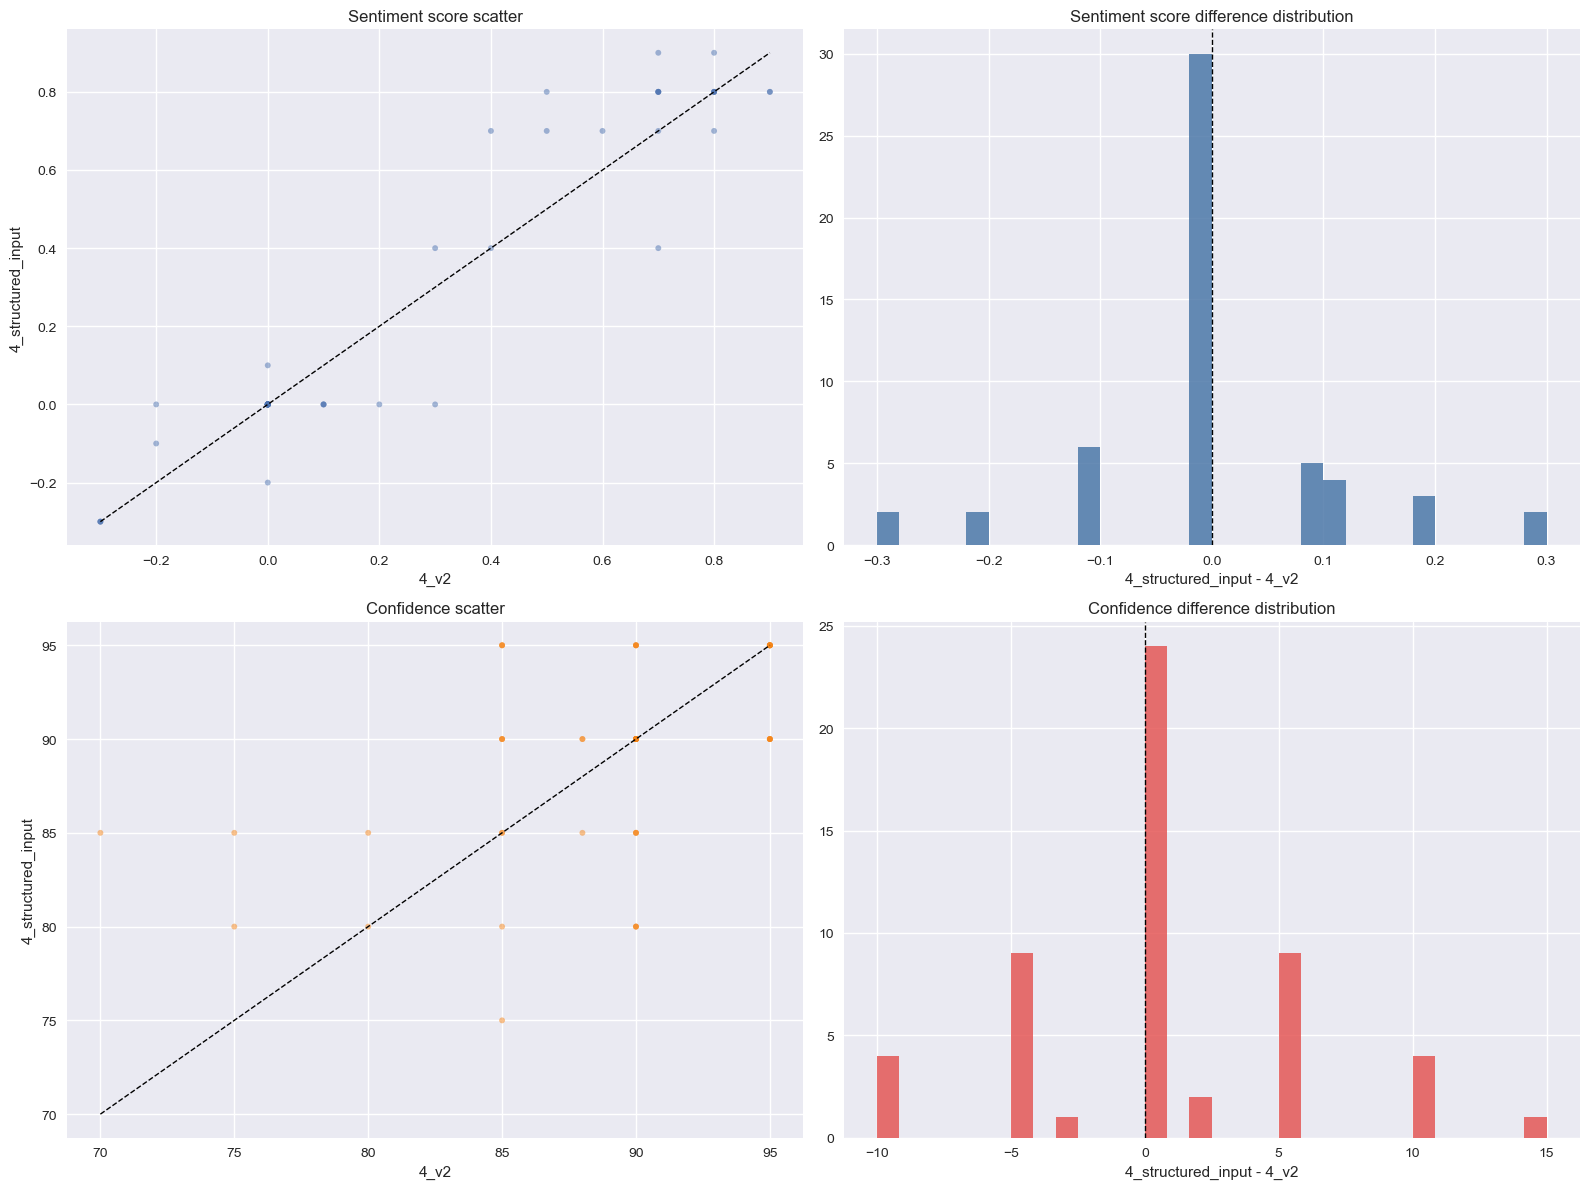

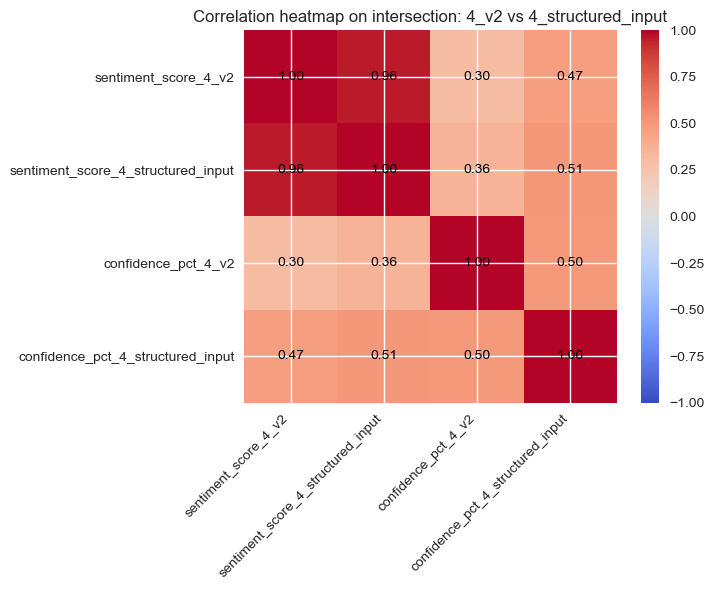

Plots for: 4_v2 vs 4_golden_structured_input


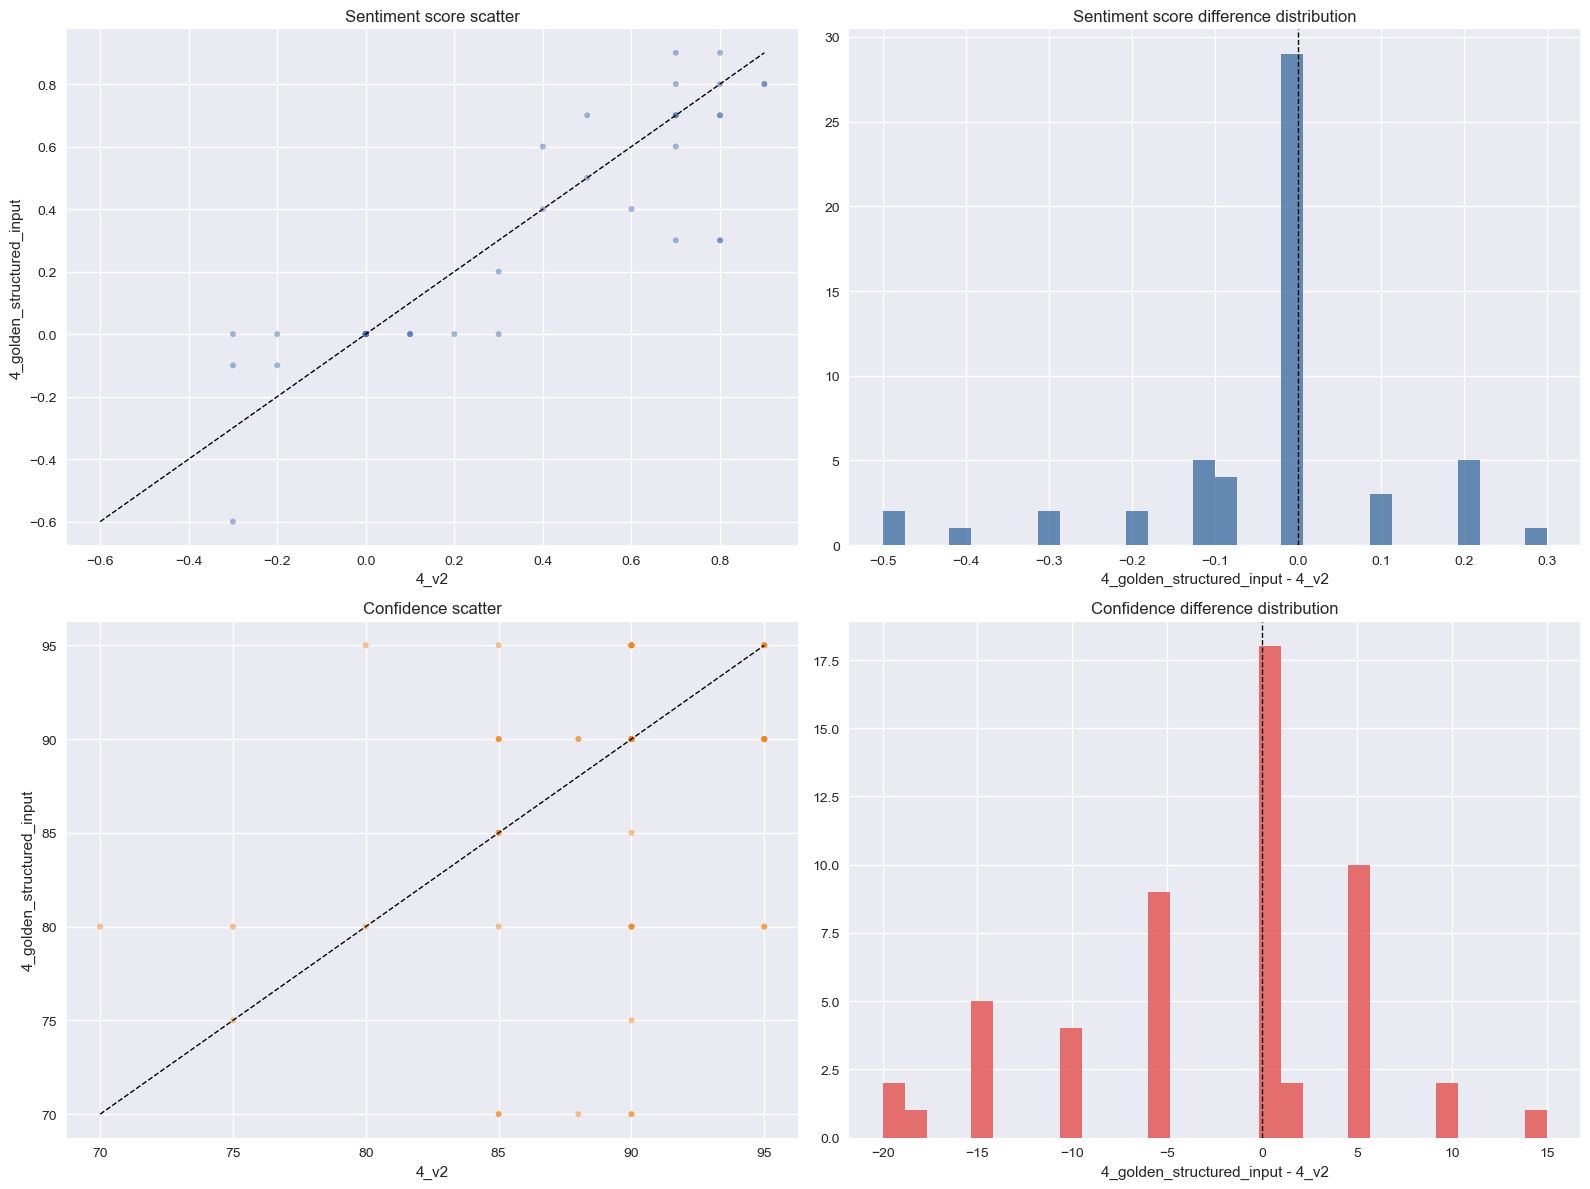

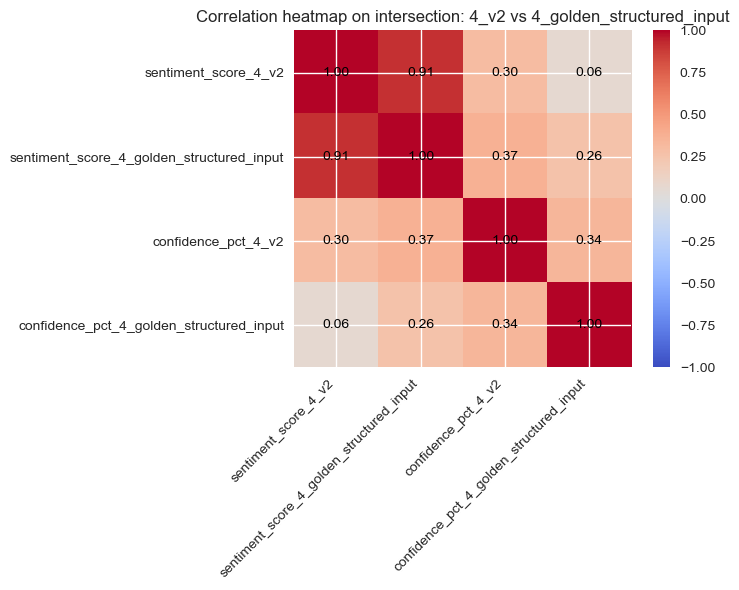

Plots for: 4_structured_input vs 4_golden_structured_input


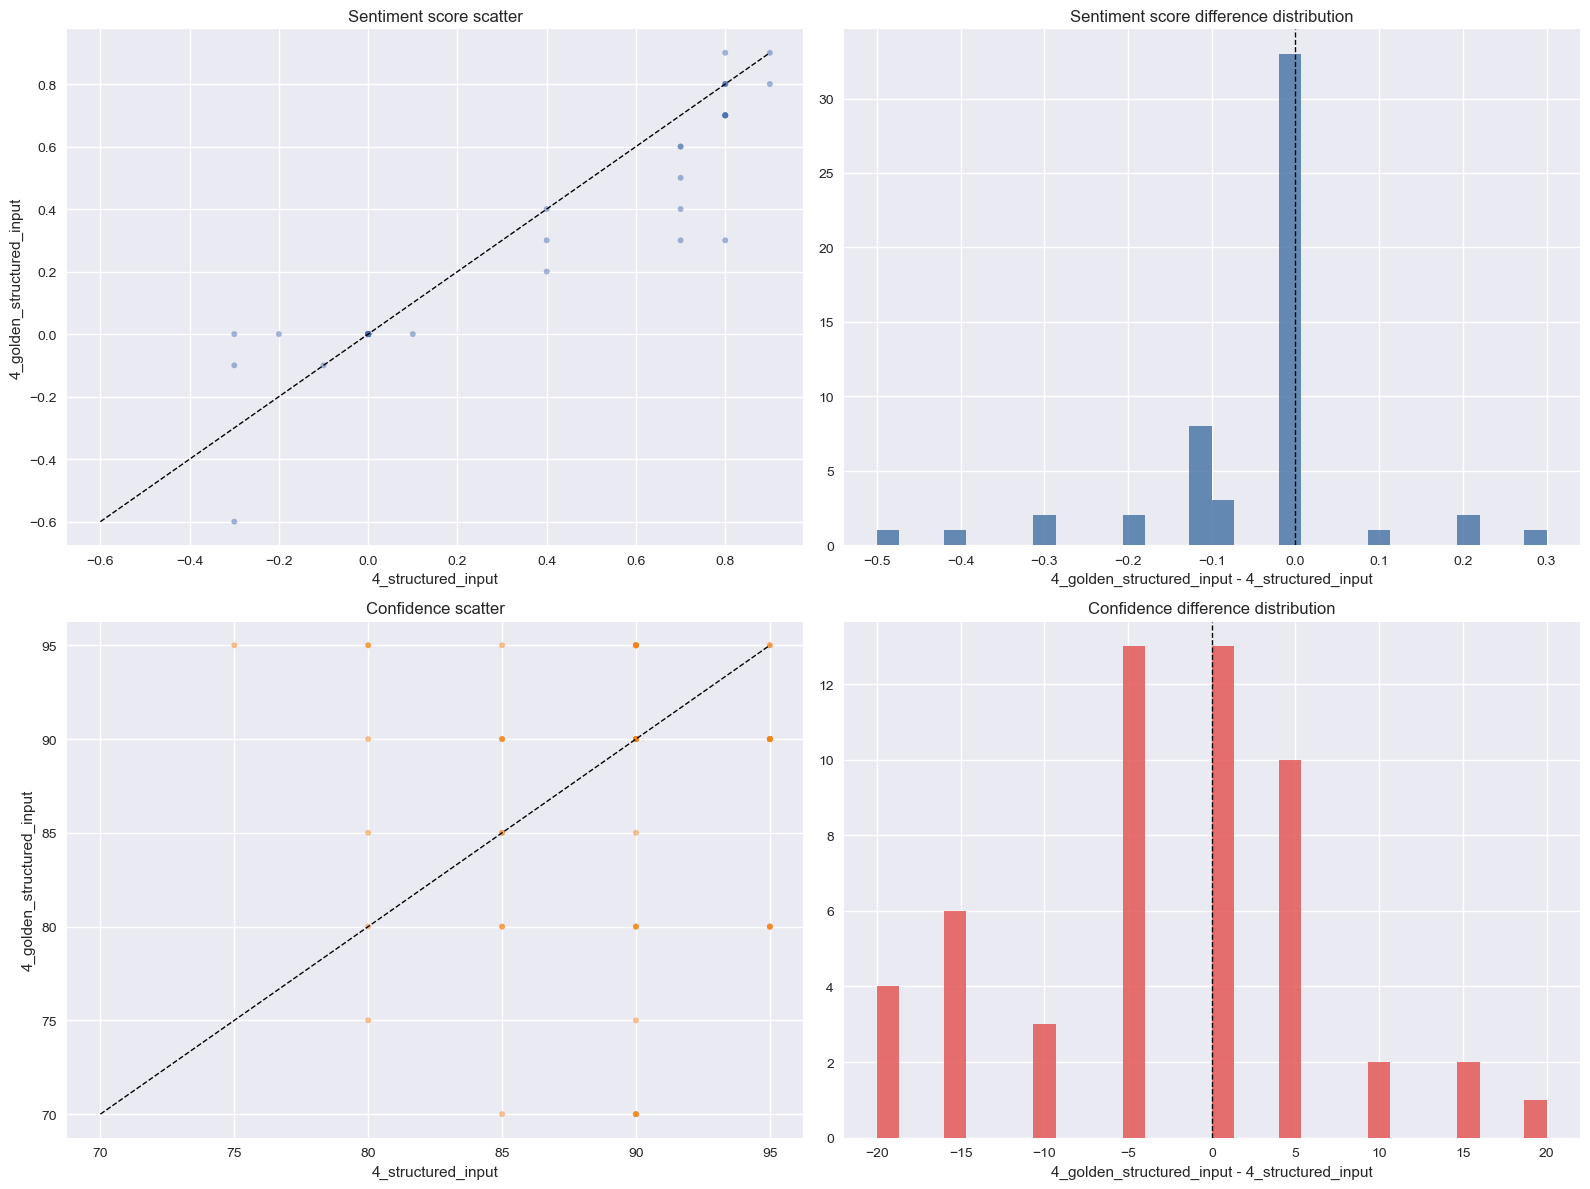

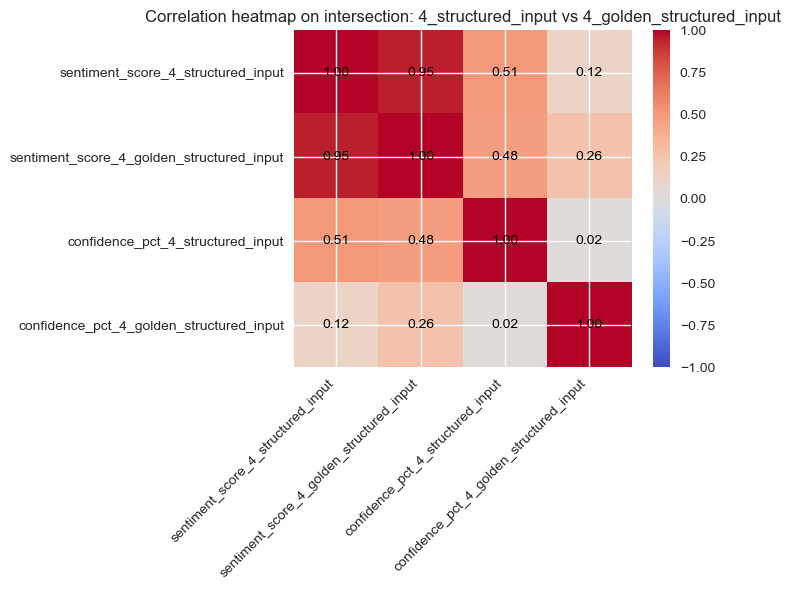

In [8]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = comparison_tables[(left_name, right_name)]
    print(f"Plots for: {left_name} vs {right_name}")

    if pair_df.empty:
        print("Skipped plots because the intersection is empty.")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    axes[0, 0].scatter(
        pair_df[f"sentiment_score_{left_name}"],
        pair_df[f"sentiment_score_{right_name}"],
        alpha=0.5,
        s=18,
        edgecolor="none",
    )
    score_values = pd.concat([
        pair_df[f"sentiment_score_{left_name}"],
        pair_df[f"sentiment_score_{right_name}"],
    ]).dropna()
    if not score_values.empty:
        score_min = score_values.min()
        score_max = score_values.max()
        axes[0, 0].plot([score_min, score_max], [score_min, score_max], linestyle="--", color="black", linewidth=1)
    axes[0, 0].set_title("Sentiment score scatter")
    axes[0, 0].set_xlabel(left_name)
    axes[0, 0].set_ylabel(right_name)

    axes[0, 1].hist(pair_df["sentiment_score_diff"].dropna(), bins=min(30, max(1, len(pair_df))), color="#4C78A8", alpha=0.85)
    axes[0, 1].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[0, 1].set_title("Sentiment score difference distribution")
    axes[0, 1].set_xlabel(f"{right_name} - {left_name}")

    axes[1, 0].scatter(
        pair_df[f"confidence_pct_{left_name}"],
        pair_df[f"confidence_pct_{right_name}"],
        alpha=0.5,
        s=18,
        edgecolor="none",
        color="#F58518",
    )
    conf_values = pd.concat([
        pair_df[f"confidence_pct_{left_name}"],
        pair_df[f"confidence_pct_{right_name}"],
    ]).dropna()
    if not conf_values.empty:
        conf_min = conf_values.min()
        conf_max = conf_values.max()
        axes[1, 0].plot([conf_min, conf_max], [conf_min, conf_max], linestyle="--", color="black", linewidth=1)
    axes[1, 0].set_title("Confidence scatter")
    axes[1, 0].set_xlabel(left_name)
    axes[1, 0].set_ylabel(right_name)

    axes[1, 1].hist(pair_df["confidence_pct_diff"].dropna(), bins=min(30, max(1, len(pair_df))), color="#E45756", alpha=0.85)
    axes[1, 1].axvline(0, linestyle="--", color="black", linewidth=1)
    axes[1, 1].set_title("Confidence difference distribution")
    axes[1, 1].set_xlabel(f"{right_name} - {left_name}")

    plt.tight_layout()
    plt.show()

    if len(pair_df) >= 2:
        corr_matrix = pair_df[[
            f"sentiment_score_{left_name}",
            f"sentiment_score_{right_name}",
            f"confidence_pct_{left_name}",
            f"confidence_pct_{right_name}",
        ]].corr()

        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_matrix.columns)))
        ax.set_yticks(range(len(corr_matrix.index)))
        ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
        ax.set_yticklabels(corr_matrix.index)

        for row_idx in range(corr_matrix.shape[0]):
            for col_idx in range(corr_matrix.shape[1]):
                ax.text(col_idx, row_idx, f"{corr_matrix.iloc[row_idx, col_idx]:.2f}", ha="center", va="center", color="black")

        ax.set_title(f"Correlation heatmap on intersection: {left_name} vs {right_name}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipped correlation heatmap because the intersection has fewer than 2 rows.")


In [9]:
for left_name, right_name in PAIRS_TO_COMPARE:
    pair_df = comparison_tables[(left_name, right_name)]
    print(f"Top {TOP_N_DIFFS} differences: {left_name} vs {right_name}")

    if pair_df.empty:
        print("Skipped detailed diff tables because the intersection is empty.")
        continue

    top_score_diffs = pair_df.nlargest(TOP_N_DIFFS, "sentiment_score_abs_diff")[
        [
            "id",
            f"sentiment_score_{left_name}",
            f"sentiment_score_{right_name}",
            "sentiment_score_diff",
            f"confidence_pct_{left_name}",
            f"confidence_pct_{right_name}",
            f"summary_{left_name}",
            f"summary_{right_name}",
        ]
    ]

    top_confidence_diffs = pair_df.nlargest(TOP_N_DIFFS, "confidence_pct_abs_diff")[
        [
            "id",
            f"confidence_pct_{left_name}",
            f"confidence_pct_{right_name}",
            "confidence_pct_diff",
            f"sentiment_score_{left_name}",
            f"sentiment_score_{right_name}",
            f"summary_{left_name}",
            f"summary_{right_name}",
        ]
    ]

    print(f"Top {TOP_N_DIFFS} sentiment_score differences")
    display(top_score_diffs)

    print(f"Top {TOP_N_DIFFS} confidence differences")
    display(top_confidence_diffs)


Top 20 differences: 4_v2 vs 4_structured_input
Top 20 sentiment_score differences


,id,sentiment_score_4_v2,sentiment_score_4_structured_input,sentiment_score_diff,confidence_pct_4_v2,confidence_pct_4_structured_input,summary_4_v2,summary_4_structured_input
0,0001213900-24-034233,0.5,0.8,0.3,85.0,95.0,This filing indicates a moderately positive se...,This filing indicates a strongly positive insi...
1,0001209191-20-021443,0.3,0.0,-0.3,75.0,85.0,This filing indicates a moderately positive in...,"This filing reports an SVP exercising 5,000 em..."
2,0001209191-20-021889,0.4,0.7,0.3,95.0,95.0,This filing reflects a moderately positive ins...,This filing indicates a strongly positive insi...
3,0001209191-20-016737,0.7,0.4,-0.3,90.0,90.0,This filing shows a strongly positive insider ...,This filing reflects a moderately positive ins...
4,0000899243-20-008213,0.7,0.9,0.2,90.0,95.0,This filing indicates a strongly positive sent...,This filing demonstrates strongly positive ins...
5,0001209191-20-019874,0.0,-0.2,-0.2,80.0,85.0,The filing presents a neutral sentiment as it ...,"This filing presents a mixed signal, leaning s..."
6,0001209191-22-045612,-0.2,0.0,0.2,88.0,85.0,This filing details a sale of 400 shares by th...,This filing reports a sale of common stock by ...
7,0001209191-20-024112,0.2,0.0,-0.2,80.0,80.0,This filing suggests a slightly positive insid...,This filing reports a Director's acquisition o...
8,0001534701-20-000072,0.5,0.7,0.2,85.0,90.0,This filing indicates a moderately positive in...,This filing reflects strongly positive insider...
9,0000899243-20-008612,0.7,0.8,0.1,88.0,90.0,This filing suggests a strong positive sentime...,This filing suggests a strongly positive insid...


Top 20 confidence differences


,id,confidence_pct_4_v2,confidence_pct_4_structured_input,confidence_pct_diff,sentiment_score_4_v2,sentiment_score_4_structured_input,summary_4_v2,summary_4_structured_input
15,0001127602-20-011102,70.0,85.0,15.0,0.1,0.0,This filing indicates a slightly positive sent...,"EVP, President and COO Gary S. Bedard reported..."
0,0001213900-24-034233,85.0,95.0,10.0,0.5,0.8,This filing indicates a moderately positive se...,This filing indicates a strongly positive insi...
1,0001209191-20-021443,75.0,85.0,10.0,0.3,0.0,This filing indicates a moderately positive in...,"This filing reports an SVP exercising 5,000 em..."
16,0001209191-20-018902,85.0,75.0,-10.0,0.0,0.1,This filing reports the grant of Restricted St...,This filing discloses the acquisition of a sub...
24,0001701605-18-000067,90.0,80.0,-10.0,0.0,0.0,This filing indicates a neutral insider sentim...,This filing reports the acquisition of Restric...
25,0001209191-22-030998,90.0,80.0,-10.0,0.0,0.0,This filing indicates a neutral sentiment as i...,"This filing reports the award of 9,724 Non-Qua..."
26,0001209191-20-017245,90.0,80.0,-10.0,0.4,0.4,This filing suggests slightly positive insider...,A Senior Executive Vice President and Head of ...
27,0000933036-21-000014,85.0,95.0,10.0,0.0,0.0,This filing reflects a neutral sentiment as th...,This filing reflects a neutral sentiment as th...
28,0000740260-22-000089,85.0,95.0,10.0,0.0,0.0,This filing conveys a neutral sentiment becaus...,This filing implies a neutral sentiment as the...
4,0000899243-20-008213,90.0,95.0,5.0,0.7,0.9,This filing indicates a strongly positive sent...,This filing demonstrates strongly positive ins...


Top 20 differences: 4_v2 vs 4_golden_structured_input
Top 20 sentiment_score differences


...

,id,confidence_pct_4_v2,confidence_pct_4_golden_structured_input,confidence_pct_diff,sentiment_score_4_v2,sentiment_score_4_golden_structured_input,summary_4_v2,summary_4_golden_structured_input
25,0000018230-19-000102,90.0,70.0,-20.0,0.0,0.0,This filing indicates a neutral sentiment as a...,A director acquired shares at a price of zero....
26,0001209191-20-025445,90.0,70.0,-20.0,0.0,0.0,"This filing indicates a director acquired 12,8...","This filing reports the acquisition of 12,858 ..."
10,0000933036-21-000095,88.0,70.0,-18.0,0.6,0.4,This filing suggests a strongly positive insid...,"Director Jeffrey J. Brown made a large, discre..."
0,0001209191-20-015600,95.0,80.0,-15.0,0.8,0.3,This filing shows a strong positive insider se...,The Chairman and CEO acquired a significant nu...
1,0001209191-22-028778,95.0,80.0,-15.0,0.8,0.3,This filing details multiple open-market purch...,This filing reports a cluster of five discreti...
16,0001209191-20-022145,85.0,70.0,-15.0,0.1,0.0,This filing indicates a slightly positive insi...,This filing reports the acquisition of deferre...
20,0001209191-20-018455,85.0,70.0,-15.0,0.3,0.2,This filing suggests a slightly positive insid...,This filing reports a discretionary purchase o...
27,0001209191-20-019874,80.0,95.0,15.0,0.0,0.0,The filing presents a neutral sentiment as it ...,President Gregory R. Raifman reported two mech...
28,0001209191-20-022112,90.0,75.0,-15.0,0.0,0.0,"This filing indicates a director acquired 1,12...","This filing reports the acquisition of 1,128 s..."
2,0001209191-20-016737,90.0,80.0,-10.0,0.7,0.3,This filing shows a strongly positive insider ...,A director made a discretionary open market pu...


Top 20 differences: 4_structured_input vs 4_golden_structured_input
Top 20 sentiment_score differences


,id,sentiment_score_4_structured_input,sentiment_score_4_golden_structured_input,sentiment_score_diff,confidence_pct_4_structured_input,confidence_pct_4_golden_structured_input,summary_4_structured_input,summary_4_golden_structured_input
0,0001209191-22-028778,0.8,0.3,-0.5,95.0,80.0,This filing details multiple substantial open-...,This filing reports a cluster of five discreti...
1,0001209191-20-015600,0.7,0.3,-0.4,95.0,80.0,This filing suggests a strongly positive insid...,The Chairman and CEO acquired a significant nu...
2,0001209191-18-061223,-0.3,0.0,0.3,85.0,90.0,The CEO and Chairman exercised a substantial n...,"This filing shows the Chairman, President & CE..."
3,0000064040-23-000067,-0.3,-0.6,-0.3,80.0,75.0,This filing indicates a slightly negative insi...,"Saugata Saha, President of Commodity Insights ..."
4,0000933036-21-000095,0.7,0.4,-0.3,90.0,70.0,This filing indicates a strongly positive sent...,"Director Jeffrey J. Brown made a large, discre..."
5,0001209191-20-018455,0.4,0.2,-0.2,90.0,70.0,Director William Henderson Cameron made an ope...,This filing reports a discretionary purchase o...
6,0001209191-20-019874,-0.2,0.0,0.2,85.0,95.0,"This filing presents a mixed signal, leaning s...",President Gregory R. Raifman reported two mech...
7,0000002488-18-000045,-0.3,-0.1,0.2,85.0,90.0,This filing reports a sale of common stock by ...,"This filing reports a large sale of 140,473 co..."
8,0001534701-20-000072,0.7,0.5,-0.2,90.0,85.0,This filing reflects strongly positive insider...,"John E. Lowe, a Director at Phillips 66, engag..."
9,0001104659-20-030766,0.8,0.7,-0.1,95.0,90.0,The CEO and a 10% owner made a significant ope...,"Marcus Lemonis, the Chief Executive Officer an..."


Top 20 confidence differences


,id,confidence_pct_4_structured_input,confidence_pct_4_golden_structured_input,confidence_pct_diff,sentiment_score_4_structured_input,sentiment_score_4_golden_structured_input,summary_4_structured_input,summary_4_golden_structured_input
4,0000933036-21-000095,90.0,70.0,-20.0,0.7,0.4,This filing indicates a strongly positive sent...,"Director Jeffrey J. Brown made a large, discre..."
5,0001209191-20-018455,90.0,70.0,-20.0,0.4,0.2,Director William Henderson Cameron made an ope...,This filing reports a discretionary purchase o...
16,0001209191-20-018902,75.0,95.0,20.0,0.1,0.0,This filing discloses the acquisition of a sub...,The Chief Executive Officer Executive Chairman...
21,0001209191-20-022145,90.0,70.0,-20.0,0.0,0.0,This filing indicates a neutral insider sentim...,This filing reports the acquisition of deferre...
22,0001209191-20-025445,90.0,70.0,-20.0,0.0,0.0,This filing reports an acquisition of common s...,"This filing reports the acquisition of 12,858 ..."
0,0001209191-22-028778,95.0,80.0,-15.0,0.8,0.3,This filing details multiple substantial open-...,This filing reports a cluster of five discreti...
1,0001209191-20-015600,95.0,80.0,-15.0,0.7,0.3,This filing suggests a strongly positive insid...,The Chairman and CEO acquired a significant nu...
23,0000018230-19-000102,85.0,70.0,-15.0,0.0,0.0,The filing reports an acquisition of common st...,A director acquired shares at a price of zero....
24,0001701605-18-000067,80.0,95.0,15.0,0.0,0.0,This filing reports the acquisition of Restric...,This filing details a Director's acquisition o...
25,0001209191-20-017945,95.0,80.0,-15.0,0.0,0.0,"Carin L. Fike, Vice President and Treasurer, e...",This filing reports acquisitions via option ex...
